# BrushCue Example: Cottagecore Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/cottagecore_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/cottagecore-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


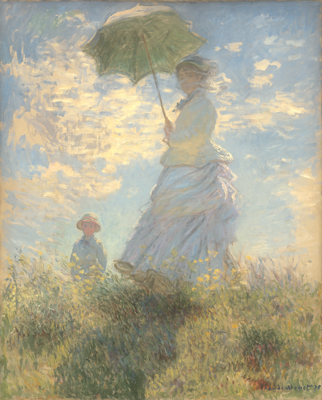

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
graded = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.01, 0.05, c);\nlet foliage = band(h, 2.4, 1.1) * colorful * amount;\nlet blue = band(h, 4.2, 1.2) * colorful * amount;\nlet h2 = h - 0.22 * foliage;\nlet c2 = c * (1.0 - 0.45 * foliage) * (1.0 - 0.3 * blue);\nvar l = input.x + 0.03 * foliage;\nl = pow(max(l, 0.0), 1.0 - 0.16 * amount);\nl = mix(l, 0.08 + l * 0.89, amount);\nlet hi = smoothstep(0.55, 0.95, l);\nlet lo = 1.0 - smoothstep(0.05, 0.4, l);\nlet a = c2 * cos(h2) + (0.006 * hi + 0.004 * lo + 0.002) * amount;\nlet b = c2 * sin(h2) + (0.034 * hi + 0.016 + 0.008 * lo) * amount;\nlet rolloff = 1.0 - smoothstep(0.92, 1.05, l);\nreturn vec4<f32>(clamp(l, 0.0, 1.0), a * rolloff, b * rolloff, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
bounds = input_image.bounds()
misted = graded.bloom(0.5, (bounds.width() * 0.025), (0.4 * strength))
graph = misted.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
